In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
os.chdir('..')
# This line lets notebook access src/eda.py
sys.path.append('..')

# Import our cleaning function from src/eda.py
from src.eda import load_and_clean

In [2]:
# Load cleaned data
df = load_and_clean()
print("✅ Data loaded!")
df.head()

✅ Data loaded!


,item_name,quantity,purchase_date,expiry_date,category,wasted,shelf_life_days
0,Milk,2,2024-01-01,2024-01-07,Dairy,1,6
1,Bread,1,2024-01-01,2024-01-05,Bakery,1,4
2,Eggs,12,2024-01-02,2024-01-20,Dairy,0,18
3,Chicken,1,2024-01-03,2024-01-06,Meat,1,3
4,Yogurt,3,2024-01-04,2024-01-10,Dairy,1,6


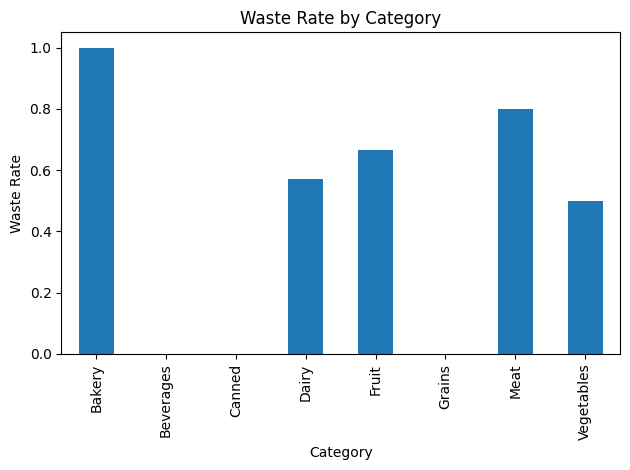

In [3]:
# Calculate waste rate per category
waste_by_category = df.groupby('category')['wasted'].mean()

# Plot bar chart of waste rate by category
waste_by_category.plot(kind='bar')
plt.title('Waste Rate by Category')
plt.xlabel('Category')
plt.ylabel('Waste Rate')
plt.tight_layout()
# Save chart to outputs folder
plt.savefig('outputs/waste_by_category.png')
plt.show()

**Insight:** Bakery and Meat categories show the highest waste rates at 100% and 80% respectively, suggesting that these perishable items are either being over-ordered or expiring before sale — making them the highest-risk categories that need immediate action through reduced ordering and dynamic discount pricing before expiry.

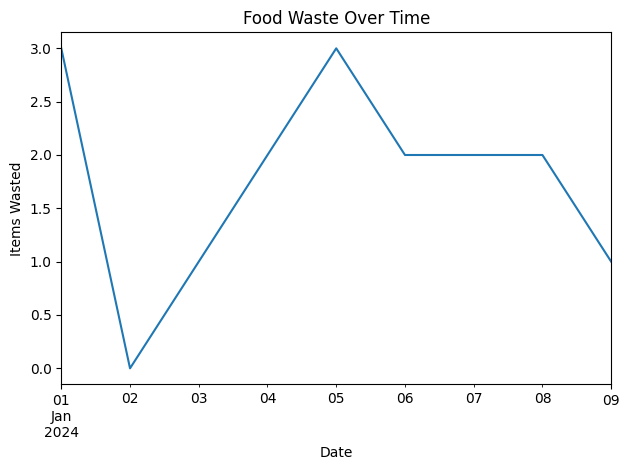

In [4]:
# Calculate total waste per purchase date
waste_over_time = df.groupby('purchase_date')['wasted'].sum()

# Plot line chart of waste over time
waste_over_time.plot(kind='line')
plt.title('Food Waste Over Time')
plt.xlabel('Date')
plt.ylabel('Items Wasted')
plt.tight_layout()
# Save chart to outputs folder
plt.savefig('outputs/waste_over_time.png')
plt.show()


**Insight:** Food waste peaked on January 5th with 3 items wasted in a single day, while January 2nd recorded zero waste — suggesting that waste is inconsistent and date-dependent, making it critical to monitor daily inventory levels and implement expiry alerts to prevent sudden waste spikes.

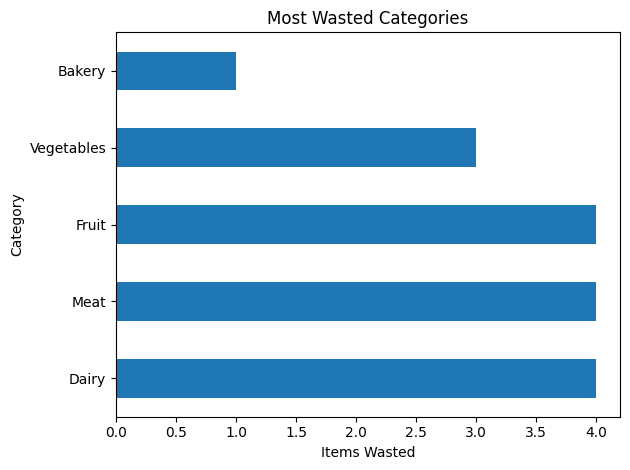

In [5]:

# Step 1: Filter only wasted items
wasted_items = df[df['wasted'] == 1]

# Step 2 & 3: Group by category and count items
category_waste_count = wasted_items.groupby('category')['item_name'].count()

# Step 4: Sort descending
category_waste_count = category_waste_count.sort_values(ascending=False)

# Step 5: Plot horizontal bar chart
category_waste_count.plot(kind='barh')
plt.title('Most Wasted Categories')
plt.xlabel('Items Wasted')
plt.ylabel('Category')
plt.tight_layout()
# Save chart to outputs folder
plt.savefig('outputs/most_wasted_items.png')
plt.show()

**Insight:** Dairy, Meat, and Fruit are the most wasted categories with 4 items each, however when combined with waste rate analysis, Meat stands out as the most dangerous category at 80% waste rate — meaning 4 out of every 5 Meat items are wasted, making it the highest priority category for immediate inventory reduction and expiry monitoring.

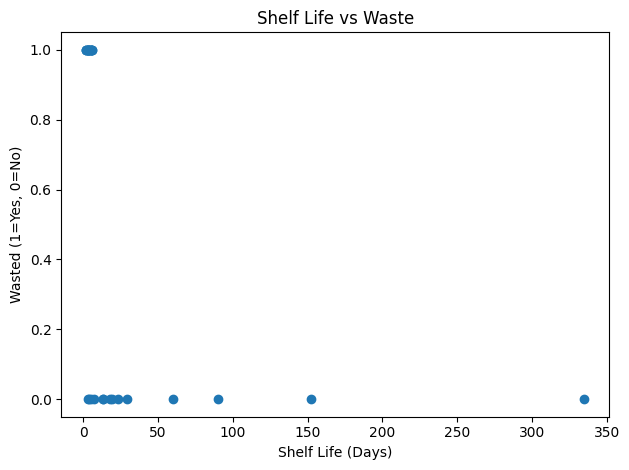

In [6]:
# Step 1: Create scatter plot
plt.scatter(x=df['shelf_life_days'], y=df['wasted'])
# Step 2: Add title
plt.title('Shelf Life vs Waste')
# Step 3: Add x label
plt.xlabel('Shelf Life (Days)')
# Step 4: Add y label
plt.ylabel('Wasted (1=Yes, 0=No)')
plt.tight_layout()
# Step 5: Save chart to outputs folder
plt.savefig('outputs/expiry_vs_waste.png')
plt.show()

**Insight:** Items wasted (y=1) are all concentrated between 0-10 days shelf life, while items not wasted (y=0) are spread across 0-350 days — clearly proving that shorter shelf life directly increases waste risk, making shelf_life_days the most critical feature for waste prediction, which was later confirmed by the Random Forest model with 50% feature importance.

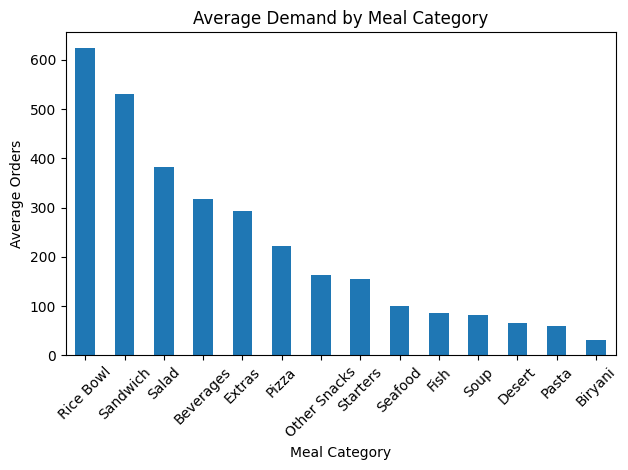

In [7]:
# Step 1: Load train dataset
df_train = pd.read_csv('data/raw/train.csv')

# Step 2: Load meal info dataset
df_meal= pd.read_csv('data/raw/meal_info.csv')

# Step 3: Merge both datasets on meal_id
df_merged = df_train.merge(df_meal , on='meal_id')

# Step 4: Calculate average orders per category
demand_by_category = df_merged.groupby('category')['num_orders'].mean()

# Step 5: Sort descending
demand_by_category = demand_by_category.sort_values(ascending=False)

# Step 6: Plot bar chart
demand_by_category.plot(kind='bar')
plt.title('Average Demand by Meal Category')
plt.xlabel('Meal Category')
plt.ylabel('Average Orders')

# Step 7: Rotate x axis labels
plt.xticks(rotation=45)

plt.tight_layout()
# Save chart to outputs folder
plt.savefig('outputs/demand_trends.png')
plt.show()

**Insight:** Rice Bowl and Sandwich are the highest demand meal categories with 620+ and 530+ average orders respectively, while Biryani has the lowest demand at under 25 orders — suggesting that kitchen resources and raw material ordering should be heavily focused on Rice Bowl and Sandwich categories to meet demand, while Biryani production should be minimized to avoid over-preparation and food waste.